In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (235795, 56)


In [3]:
df.head

<bound method NDFrame.head of            FILENAME                                                URL  \
0        521848.txt                   https://www.southbankmosaics.com   
1         31372.txt                           https://www.uni-mainz.de   
2        597387.txt                     https://www.voicefmradio.co.uk   
3        554095.txt                        https://www.sfnmjournal.com   
4        151578.txt                 https://www.rewildingargentina.org   
...             ...                                                ...   
235790   660997.txt                     https://www.skincareliving.com   
235791    77185.txt                      https://www.winchester.gov.uk   
235792   622132.txt                    https://www.nononsensedesign.be   
235793  7503962.txt  https://patient-cell-40f5.updatedlogmylogin.wo...   
235794   384822.txt                 https://www.alternativefinland.com   

        URLLength                                           Domain  \
0          

In [5]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [7]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [8]:
df["label"].value_counts(normalize=True) * 100

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64

In [9]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [10]:
df.groupby("label").size()

label
0    100945
1    134850
dtype: int64

In [11]:
df[df["label"] == 0][["URL", "label"]].head(10)

,URL,label
11,http://www.teramill.com,0
20,http://www.f0519141.xsph.ru,0
21,http://www.shprakserf.gq,0
27,https://service-mitld.firebaseapp.com/,0
28,http://www.kuradox92.lima-city.de,0
29,https://liuy-9a930.web.app/,0
31,https://ipfs.io/ipfs/qmrvvyr84esa2assw9vvwupqj...,0
32,http://att-103731-107123.weeblysite.com/,0
34,https://hidok4f8zl.firebaseapp.com/,0
37,http://www.ooguy.com,0


In [12]:
df[df["label"] == 1][["URL", "label"]].head(10)

,URL,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1
5,https://www.globalreporting.org,1
6,https://www.saffronart.com,1
7,https://www.nerdscandy.com,1
8,https://www.hyderabadonline.in,1
9,https://www.aap.org,1


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["URL"].duplicated().sum()

np.int64(425)

In [15]:
df[df["label"] == 0][["URL", "label"]].head(10)
df[df["label"] == 1][["URL", "label"]].head(10)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate URLs:", df["URL"].duplicated().sum())

Duplicate rows: 0
Duplicate URLs: 425


In [16]:
print(repr(df["URL"].iloc[0]))
print(repr(df["URL"].iloc[235793]))

'https://www.southbankmosaics.com'
'https://patient-cell-40f5.updatedlogmylogin.workers.dev/'


In [17]:
duplicate_urls = df[df["URL"].duplicated(keep=False)].sort_values("URL")

duplicate_urls[["URL", "label"]].head(20)

,URL,label
57609,http://2f3a.reicrut-chat.workers.dev/,0
219489,http://2f3a.reicrut-chat.workers.dev/,0
27166,http://34.149.138.117/,0
227564,http://34.149.138.117/,0
147448,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
189978,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
31955,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
57315,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
126246,http://91.239.125.28/postchs/sms.php,0
197956,http://91.239.125.28/postchs/sms.php,0


In [18]:
duplicate_urls.groupby("URL")["label"].nunique().value_counts()

label
1    425
Name: count, dtype: int64

In [19]:
print(df.groupby("label")["URL"].count())

label
0    100945
1    134850
Name: URL, dtype: int64


In [20]:
print("\nLabel 0:")
print(df[df["label"] == 0]["URL"].head(5).to_string(index=False))

print("\nLabel 1:")
print(df[df["label"] == 1]["URL"].head(5).to_string(index=False))


Label 0:
               http://www.teramill.com
           http://www.f0519141.xsph.ru
              http://www.shprakserf.gq
https://service-mitld.firebaseapp.com/
     http://www.kuradox92.lima-city.de

Label 1:
  https://www.southbankmosaics.com
          https://www.uni-mainz.de
    https://www.voicefmradio.co.uk
       https://www.sfnmjournal.com
https://www.rewildingargentina.org


In [21]:
import re

def clean_url(url):
    match = re.search(r'\((https?://[^)]+)\)', url)
    if match:
        return match.group(1)
    return url

df["CleanURL"] = df["URL"].apply(clean_url)

print(df[["URL", "CleanURL"]].head(10).to_string(index=False))

                               URL                           CleanURL
  https://www.southbankmosaics.com   https://www.southbankmosaics.com
          https://www.uni-mainz.de           https://www.uni-mainz.de
    https://www.voicefmradio.co.uk     https://www.voicefmradio.co.uk
       https://www.sfnmjournal.com        https://www.sfnmjournal.com
https://www.rewildingargentina.org https://www.rewildingargentina.org
   https://www.globalreporting.org    https://www.globalreporting.org
        https://www.saffronart.com         https://www.saffronart.com
        https://www.nerdscandy.com         https://www.nerdscandy.com
    https://www.hyderabadonline.in     https://www.hyderabadonline.in
               https://www.aap.org                https://www.aap.org


In [22]:
print(df[["URLLength", "CleanURL"]].head(10))

   URLLength                            CleanURL
0         31    https://www.southbankmosaics.com
1         23            https://www.uni-mainz.de
2         29      https://www.voicefmradio.co.uk
3         26         https://www.sfnmjournal.com
4         33  https://www.rewildingargentina.org
5         30     https://www.globalreporting.org
6         25          https://www.saffronart.com
7         25          https://www.nerdscandy.com
8         29      https://www.hyderabadonline.in
9         18                 https://www.aap.org


In [23]:
df["CalculatedURLLength"] = df["CleanURL"].str.len()

print(
    df[["URLLength", "CalculatedURLLength"]].head(20).to_string(index=False)
)

 URLLength  CalculatedURLLength
        31                   32
        23                   24
        29                   30
        26                   27
        33                   34
        30                   31
        25                   26
        25                   26
        29                   30
        18                   19
        33                   34
        22                   23
        27                   28
        20                   21
        26                   27
        24                   25
        20                   21
        21                   22
        21                   22
        22                   23


In [24]:
duplicate_urls = df[df["URL"].duplicated(keep=False)].sort_values("URL")

print(duplicate_urls[["URL", "label"]].head(20).to_string(index=False))

                                                                                       URL  label
                                                     http://2f3a.reicrut-chat.workers.dev/      0
                                                     http://2f3a.reicrut-chat.workers.dev/      0
                                                                    http://34.149.138.117/      0
                                                                    http://34.149.138.117/      0
                           http://595221.selcdn.ru/qwerty-ohdhdjejnnad-najahhy/index4.html      0
                           http://595221.selcdn.ru/qwerty-ohdhdjejnnad-najahhy/index4.html      0
                           http://595221.selcdn.ru/qwerty-ohdhdjejnnad-najahhy/index8.html      0
                           http://595221.selcdn.ru/qwerty-ohdhdjejnnad-najahhy/index8.html      0
                                                      http://91.239.125.28/postchs/sms.php      0
                    

In [25]:
print(
    duplicate_urls.groupby("URL")["label"]
    .nunique()
    .value_counts()
)

label
1    425
Name: count, dtype: int64


In [26]:
print(
    duplicate_urls.groupby("URL")["label"]
    .nunique()
    .value_counts()
)

label
1    425
Name: count, dtype: int64


In [27]:
conflicting_urls = (
    df.groupby("URL")["label"]
    .nunique()
)

print("URLs with conflicting labels:", (conflicting_urls > 1).sum())

URLs with conflicting labels: 0


In [28]:
df_clean = df.drop_duplicates(subset="URL").copy()

print("Original rows:", len(df))
print("After removing duplicate URLs:", len(df_clean))

Original rows: 235795
After removing duplicate URLs: 235370


In [29]:
print(df_clean["label"].value_counts())

label
1    134850
0    100520
Name: count, dtype: int64


In [30]:
print(df_clean["label"].value_counts(normalize=True) * 100)

label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [31]:
df_clean["label"].value_counts(normalize=True) * 100

label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

In [33]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

In [35]:
X = df_clean[url_features]
y = df_clean["label"]

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235370, 18)
y shape: (235370,)


In [37]:
print(X.dtypes)

URLLength                       int64
DomainLength                    int64
IsDomainIP                      int64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
dtype: object


In [38]:
print(X.isnull().sum().sum())

0


In [39]:
print(X.describe().T)

                               count       mean        std   min     25%  \
URLLength                   235370.0  34.545516  41.332730  13.0  23.000   
DomainLength                235370.0  21.456022   9.127733   4.0  16.000   
IsDomainIP                  235370.0   0.002702   0.051912   0.0   0.000   
TLDLength                   235370.0   2.764269   0.599667   2.0   2.000   
NoOfSubDomain               235370.0   1.164957   0.600695   0.0   1.000   
HasObfuscation              235370.0   0.002052   0.045254   0.0   0.000   
NoOfObfuscatedChar          235370.0   0.024880   1.877922   0.0   0.000   
ObfuscationRatio            235370.0   0.000138   0.003818   0.0   0.000   
NoOfLettersInURL            235370.0  19.405600  29.099537   0.0  10.000   
LetterRatioInURL            235370.0   0.515749   0.123234   0.0   0.435   
NoOfDegitsInURL             235370.0   1.875732  11.892529   0.0   0.000   
DegitRatioInURL             235370.0   0.028516   0.070801   0.0   0.000   
NoOfEqualsIn

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (188296, 18)
Testing features: (47074, 18)
Training labels: (188296,)
Testing labels: (47074,)


In [41]:
print("Training label distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training label distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

Testing label distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [45]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [46]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [47]:
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.9959425585248757
Precision: 0.9932947721327783
Recall   : 0.9996662958843159
F1 Score : 0.9964703490843235
ROC-AUC  : 0.9981262986788315


In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20104
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Phishing probability = probability of class 0
y_prob_phishing_lr = logistic_model.predict_proba(X_test_scaled)[:, 0]

print("Logistic Regression Results")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label=0))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label=0))
print("F1 Score :", f1_score(y_test, y_pred_lr, pos_label=0))

# ROC-AUC for phishing class
roc_auc_lr = roc_auc_score(
    (y_test == 0).astype(int),
    y_prob_phishing_lr
)

print("ROC-AUC  :", roc_auc_lr)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    labels=[0, 1],
    target_names=["Phishing (0)", "Legitimate (1)"]
))

Logistic Regression Results
------------------------------
Accuracy : 0.9959425585248757
Precision: 0.9995484421253324
Recall   : 0.9909470752089137
F1 Score : 0.9952291744723367
ROC-AUC  : 0.9981262986788313

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      0.99      1.00     20104
Legitimate (1)       0.99      1.00      1.00     26970

      accuracy                           1.00     47074
     macro avg       1.00      1.00      1.00     47074
  weighted avg       1.00      1.00      1.00     47074



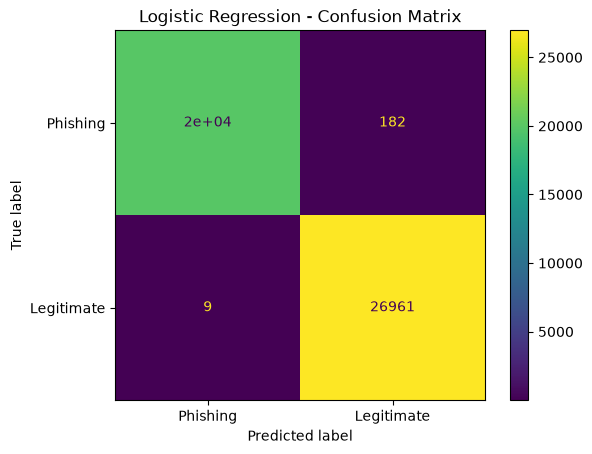

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Phishing", "Legitimate"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [55]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [56]:
y_pred_rf = random_forest.predict(X_test)

y_prob_phishing_rf = random_forest.predict_proba(X_test)[:, 0]

In [57]:
print("Random Forest Results")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("Precision:", precision_score(
    y_test, y_pred_rf, pos_label=0
))

print("Recall   :", recall_score(
    y_test, y_pred_rf, pos_label=0
))

print("F1 Score :", f1_score(
    y_test, y_pred_rf, pos_label=0
))

roc_auc_rf = roc_auc_score(
    (y_test == 0).astype(int),
    y_prob_phishing_rf
)

print("ROC-AUC  :", roc_auc_rf)

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred_rf,
    labels=[0, 1],
    target_names=["Phishing (0)", "Legitimate (1)"]
))

Random Forest Results
------------------------------
Accuracy : 0.9973658495135319
Precision: 0.9991007194244604
Recall   : 0.9947274174293673
F1 Score : 0.9969092721834496
ROC-AUC  : 0.9981960951734702

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      0.99      1.00     20104
Legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47074
     macro avg       1.00      1.00      1.00     47074
  weighted avg       1.00      1.00      1.00     47074



In [59]:
n_estimators=100


In [60]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgboost_model.fit(X_train, y_train)

ModuleNotFoundError: No module named 'xgboost'

In [62]:
%pip install xgboost

  Using cached xgboost-3.4.1-py3-none-macosx_12_0_arm64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-macosx_12_0_arm64.whl (2.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


NameError: name 'X_test' is not defined